# Systembezug-Netzwerkanalyse — finale Auswertung

Dieses Notebook liest die Metrik-Datei **mit Systembezug** ein
(`Knotenmetriken` + `Kantenliste`) und erzeugt die interpretativen Endauswertungen
des Inferenzgraphen:

1. Systembezug-Verteilung (LIT / NLIT / LIT-NLIT)
2. Kanten über die Systemgrenze — der zentrale Befund der *vermittelten* Grenze
3. Zentralität nach Systembezug (sind die LIT-NLIT-Knoten die Brücken?)
4. Woran wird Literatur geknüpft? — Häufigkeit der NLIT-Gegenstände
5. **(a)** LIT-NLIT-Knoten mit der höchsten Betweenness (die Scharnierstellen)
6. **(b)** Entwicklung über die literarhistorische Zeit (Tabelle + Diagramme)

Es werden **keine API-Aufrufe** benötigt — reine Analyse der bereits erzeugten Daten.
Alle Ergebnisse werden zusätzlich nach `analyse_outputs/` exportiert.

> **Konventions-Hinweis:** Bei gerichteten Kanten kodiert `von → nach` die Richtung
> *Grund → gestützte Aussage* (wie in den Intra-Daten). Die Richtungsauswertung
> in Abschnitt 2/b ist entsprechend zu lesen.

## 0. Setup & Konfiguration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

# === Konfiguration — hier ggf. anpassen ===
INPUT_XLSX     = "Beutin_complete_Direktzitat_metriken.xlsx"  # Metrik-Datei MIT Systembezug
OUTPUT_DIR     = Path("analyse_outputs"); OUTPUT_DIR.mkdir(exist_ok=True)
TOP_N_BRUECKEN = 30   # Anzahl auszulesender LIT-NLIT-Brückenknoten

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
pd.set_option("display.max_colwidth", 70)

## 1. Daten laden und vorbereiten

Wir laden die Knoten- und Kantentabelle. Die **Kapitel-Reihenfolge** wird aus dem
ersten Auftreten je Kapitel in der Knotentabelle abgeleitet — das entspricht der
literarhistorischen Abfolge im Buch. Anschließend wird der Systembezug der beiden
Endpunkte an jede Kante angefügt, damit wir Kanten über die Systemgrenze erkennen.

In [2]:
sheets = pd.read_excel(INPUT_XLSX, sheet_name=None)
nodes  = sheets["Knotenmetriken"].copy()
edges  = sheets["Kantenliste"].copy()

# Numerische Spalten absichern
for c in ["In-Degree", "Out-Degree", "Betweenness"]:
    nodes[c] = pd.to_numeric(nodes[c], errors="coerce").fillna(0)
nodes["Systembezug"] = nodes["Systembezug"].fillna("(ohne)")

# Kapitel-Reihenfolge = erstes Auftreten (= chronologische Abfolge im Buch)
# Chronologische Buchreihenfolge: Kapitel nach der kleinsten Satznummer ordnen
# (die Proposition-IDs P(<satznr>.<n>) sind in Leserichtung durchnummeriert).
nodes["_pnum"] = nodes["Propositions-ID"].str.extract(r"P\((\d+)").astype(float)
chapter_order = (nodes[nodes.Kapitel != "(Unbekannt)"]
                 .groupby("Kapitel")["_pnum"].min().sort_values().index.tolist())

# Nachschlagetabellen Knoten -> Systembezug / Kapitel
sb = dict(zip(nodes["Propositions-ID"], nodes["Systembezug"]))
ch = dict(zip(nodes["Propositions-ID"], nodes["Kapitel"]))

# Systembezug der Endpunkte + Kapitel an die Kanten anfügen
edges["sb_von"]  = edges["von"].map(sb)
edges["sb_nach"] = edges["nach"].map(sb)
edges["kapitel"] = edges["von"].map(ch)

print(f"{len(nodes):,} Knoten | {len(edges):,} Kanten | {len(chapter_order)} Kapitel (chronologisch)")

29,446 Knoten | 15,624 Kanten | 15 Kapitel (chronologisch)


## 2. Systembezug-Verteilung

Grundzusammensetzung des Textes auf Propositionsebene.

In [3]:
vert = nodes["Systembezug"].value_counts()
verteilung = pd.DataFrame({"Anzahl": vert,
                           "Anteil %": (vert / len(nodes) * 100).round(1)})
verteilung

,Anzahl,Anteil %
Systembezug,,
LIT,16888,57.4
LIT-NLIT,7572,25.7
NLIT,4986,16.9


## 3. Kanten über die Systemgrenze — die *vermittelte* Grenze

Kernfrage: Wie viel Inferenz überschreitet die Grenze zwischen literarischem und
nicht-literarischem System? Wir klassifizieren jede Kante nach dem (ungerichteten)
System-Paar ihrer Endpunkte und unterscheiden dann:

- **direkte** Grenzüberschreitung (ein Endpunkt LIT, der andere NLIT) und
- über **LIT-NLIT-Brückenknoten vermittelte** Verbindungen.

In [4]:
edges["paar"] = ["\u2013".join(sorted([str(a), str(b)]))
                 for a, b in zip(edges.sb_von, edges.sb_nach)]
paar = edges["paar"].value_counts()
paar_tab = pd.DataFrame({"Kanten": paar, "Anteil %": (paar / len(edges) * 100).round(1)})
display(paar_tab)

involves = edges[(edges.sb_von == "LIT-NLIT") | (edges.sb_nach == "LIT-NLIT")]
direct   = edges[((edges.sb_von == "LIT")  & (edges.sb_nach == "NLIT")) |
                 ((edges.sb_von == "NLIT") & (edges.sb_nach == "LIT"))]

print(f"Über LIT-NLIT-Knoten vermittelt : {len(involves):>6,}  ({len(involves)/len(edges)*100:.1f}%)")
print(f"Direkte LIT<->NLIT-Grenze       : {len(direct):>6,}  ({len(direct)/len(edges)*100:.1f}%)")
print("Richtung der direkten Kanten (von -> nach):")
print(direct.groupby(["sb_von", "sb_nach"]).size().to_string())
print("\nDirekte Grenzkanten nach Relationstyp:")
print(direct["typ"].value_counts().to_string())

,Kanten,Anteil %
paar,,
LIT–LIT,6989,44.7
LIT–LIT-NLIT,2734,17.5
LIT-NLIT–LIT-NLIT,2529,16.2
NLIT–NLIT,1903,12.2
LIT-NLIT–NLIT,1083,6.9
LIT–NLIT,386,2.5


Über LIT-NLIT-Knoten vermittelt :  6,346  (40.6%)
Direkte LIT<->NLIT-Grenze       :    386  (2.5%)
Richtung der direkten Kanten (von -> nach):
sb_von  sb_nach
LIT     NLIT       119
NLIT    LIT        267

Direkte Grenzkanten nach Relationstyp:
typ
PR-BER    361
PR-INK     16
PR-FLG      9


## 4. Zentralität nach Systembezug

Tragen die LIT-NLIT-Propositionen tatsächlich die Verbindungslast? Wir vergleichen
mittlere Betweenness, mittleren Grad und Isolationsrate je Systembezug.

In [5]:
nodes["grad"]     = nodes["In-Degree"] + nodes["Out-Degree"]
nodes["isoliert"] = nodes["grad"] == 0

zent = (nodes.groupby("Systembezug")
        .agg(n=("Propositions-ID", "size"),
             Ø_Betweenness=("Betweenness", "mean"),
             Ø_Grad=("grad", "mean"),
             isoliert_pct=("isoliert", lambda s: s.mean() * 100))
        .round(2)
        .reindex(["LIT", "NLIT", "LIT-NLIT"]))
zent

,n,Ø_Betweenness,Ø_Grad,isoliert_pct
Systembezug,,,,
LIT,16888,0.36,1.01,30.29
NLIT,4986,0.40,1.06,28.36
LIT-NLIT,7572,0.46,1.17,22.60


## 5. Woran wird Literatur geknüpft? — NLIT-Gegenstände

Häufigkeit der extrahierten nicht-literarischen Gegenstände über alle
LIT-NLIT-Propositionen. Diese Frequenzliste ist die Grundlage für die spätere
Domänen-Clusterung und das Regelmäßigkeits-Kriterium der Normativität.

In [6]:
ln = nodes[nodes.Systembezug == "LIT-NLIT"].copy()
nlit_freq = (ln["NLIT-Gegenstand"].dropna().astype(str).str.strip()
             .loc[lambda s: s != ""].value_counts())
nlit_freq.head(40).to_frame("Häufigkeit").to_excel(OUTPUT_DIR / "nlit_gegenstaende_top40.xlsx")
print("Top 20 NLIT-Gegenstände:")
nlit_freq.head(20)

Top 20 NLIT-Gegenstände:


NLIT-Gegenstand
DDR                        48
Politik                    27
Faschismus                 27
Exil                       20
Nationalsozialismus        20
Deutschland                19
Weimarer Republik          19
Französische Revolution    19
Bundesrepublik             18
Reformation                16
Zensur                     16
Revolution                 14
Wirklichkeit               14
Revolution von 1848        14
Nationalsozialisten        13
Realität                   12
Gesellschaft               12
neue Medien                10
Geschichte                  9
Frauen                      9
Name: count, dtype: int64

## (a) LIT-NLIT-Knoten mit der höchsten Betweenness

Die Scharnierstellen des Graphen: jene Verknüpfungspropositionen, über die die
meisten kürzesten Pfade laufen. Sie eignen sich als interpretative Anker für ein
anschließendes Close Reading. Export nach `lit_nlit_bruecken_top.xlsx`.

In [7]:
bruecken = (ln.sort_values("Betweenness", ascending=False)
            .head(TOP_N_BRUECKEN)
            [["Propositions-ID", "Kapitel", "Betweenness", "grad",
              "LIT-Gegenstand", "NLIT-Gegenstand", "Proposition"]]
            .reset_index(drop=True))
bruecken.index += 1
bruecken.to_excel(OUTPUT_DIR / "lit_nlit_bruecken_top.xlsx")

# Kompakte Anzeige (Volltext in der Exportdatei)
display(bruecken[["Propositions-ID", "Kapitel", "Betweenness",
                  "LIT-Gegenstand", "NLIT-Gegenstand"]])

,Propositions-ID,Kapitel,Betweenness,LIT-Gegenstand,NLIT-Gegenstand
1,P(3403.5),Vormärz,18.0,vom Verbot bedrohte Literatur,finanzielles Risiko der Verleger
2,P(6850.1),Die Literatur der DDR,16.0,Autoren,Zensoren
3,P(3403.6),Vormärz,16.0,"oppositionelle Schriftsteller, Journalisten",Profitinteresse des bürgerlichen Kapitals
4,P(5423.4),Literatur in der Weimarer Republik,15.0,bürgerliche Intellektuelle (gestaltend),Autoritarismus der Kleinfamilie
5,P(2447.1),Aufklärung,15.0,Fabel als Dichtung,gemeiner pövel
6,P(3279.1),Kunstepoche,14.0,das Klassische,nationale Identität
7,P(3678.1),Vormärz,12.0,politisch eingreifende Dichtung Herweghs,politisches Eingreifen
8,P(2049.2),Aufklärung,12.0,Schriftsteller,Fürsten
9,P(2563.1),Kunstepoche,12.0,Autonomieforderung,politische Instrumentalisierung
10,P(6494.4),Deutsche Literatur nach 1945,12.0,Zeitschrift Der Ruf,amerikanische Militärregierung


## (b) Entwicklung über die Zeit

Pro Kapitel (chronologisch): Systembezug-Anteile, Verknüpfungsintensität und
Grenzüberschreitung. So lässt sich verfolgen, **wo** Beutin Literatur am stärksten
an Geschichte koppelt und wie sich das über die Epochen verschiebt.

In [8]:
rows = []
for c in chapter_order:
    nd = nodes[nodes.Kapitel == c]; ed = edges[edges.kapitel == c]
    n, m = len(nd), len(ed)
    dirc = (((ed.sb_von=="LIT") & (ed.sb_nach=="NLIT")) |
            ((ed.sb_von=="NLIT") & (ed.sb_nach=="LIT"))).sum()
    nlit2lit = ((ed.sb_von=="NLIT") & (ed.sb_nach=="LIT")).sum()
    inv = ((ed.sb_von=="LIT-NLIT") | (ed.sb_nach=="LIT-NLIT")).sum()
    rows.append({
        "Kapitel": c, "Propositionen": n,
        "LIT %":      round((nd.Systembezug=="LIT").sum()/n*100, 1) if n else 0,
        "LIT-NLIT %": round((nd.Systembezug=="LIT-NLIT").sum()/n*100, 1) if n else 0,
        "NLIT %":     round((nd.Systembezug=="NLIT").sum()/n*100, 1) if n else 0,
        "Kanten": m,
        "über LIT-NLIT %": round(inv/m*100, 1) if m else 0,
        "direkt LIT-NLIT %": round(dirc/m*100, 2) if m else 0,
        "NLIT→LIT-Anteil direkt %": round(nlit2lit/dirc*100, 1) if dirc else np.nan,
    })
zeit = pd.DataFrame(rows)
zeit.to_excel(OUTPUT_DIR / "entwicklung_ueber_zeit.xlsx", index=False)
zeit

,Kapitel,Propositionen,LIT %,LIT-NLIT %,NLIT %,Kanten,über LIT-NLIT %,direkt LIT-NLIT %,NLIT→LIT-Anteil direkt %
0,Mittelalterliche Literatur,2089,57.0,17.5,25.5,1068,29.0,1.31,71.4
1,Humanismus und Reformation,1856,43.3,22.7,33.9,953,38.1,3.04,48.3
2,Literatur des Barock,1587,67.3,15.2,17.5,883,25.1,2.04,44.4
3,Aufklärung,1255,61.2,27.3,11.6,850,42.6,0.94,75.0
4,Kunstepoche,2131,62.6,24.2,13.1,1242,39.0,1.77,54.5
5,Vormärz,1794,40.5,40.2,19.3,953,62.1,2.94,75.0
6,Realismus und Gründerzeit,1883,61.1,21.6,17.3,1014,33.7,3.75,68.4
7,Die literarische Moderne (1890–1920),1691,60.3,23.7,16.1,902,36.6,2.77,68.0
8,Literatur in der Weimarer Republik,1765,49.5,33.8,16.7,978,51.2,1.84,88.9
9,Literatur im Dritten Reich,634,30.3,52.2,17.5,360,76.9,1.67,50.0


### Diagramm 1 — Systembezug-Zusammensetzung über die Epochen

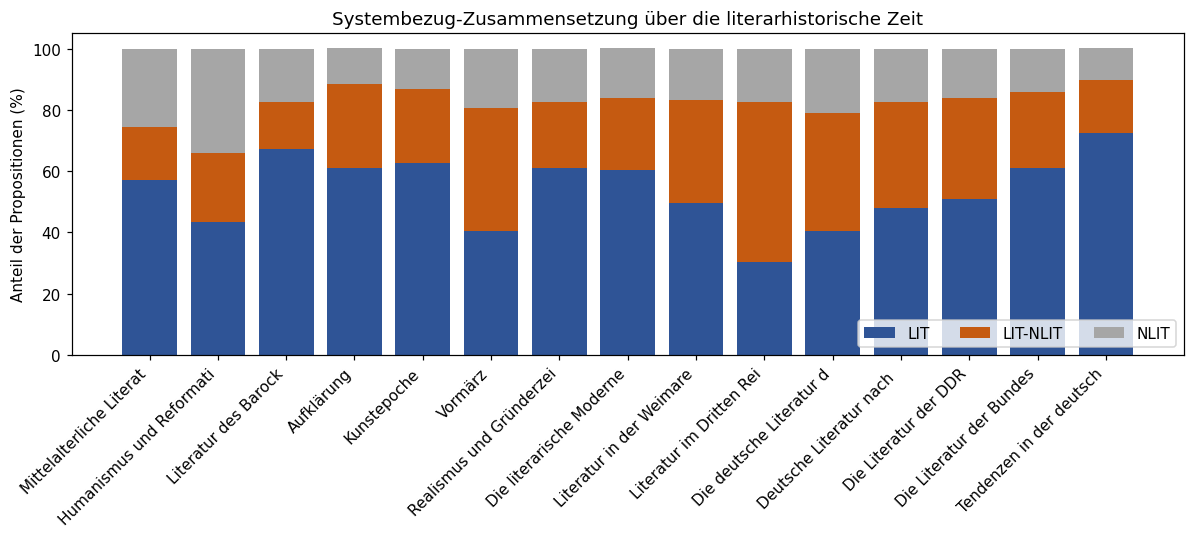

In [9]:
labels = [c[:24] for c in zeit.Kapitel]
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(labels, zeit["LIT %"], label="LIT", color="#2F5496")
ax.bar(labels, zeit["LIT-NLIT %"], bottom=zeit["LIT %"], label="LIT-NLIT", color="#C55A11")
ax.bar(labels, zeit["NLIT %"], bottom=zeit["LIT %"]+zeit["LIT-NLIT %"], label="NLIT", color="#A6A6A6")
ax.set_ylabel("Anteil der Propositionen (%)")
ax.set_title("Systembezug-Zusammensetzung über die literarhistorische Zeit")
ax.legend(loc="lower right", ncol=3)
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "zeit_zusammensetzung.png", dpi=130, bbox_inches="tight")
plt.show()

### Diagramm 2 — Verknüpfungsintensität Literatur ↔ Geschichte über die Zeit

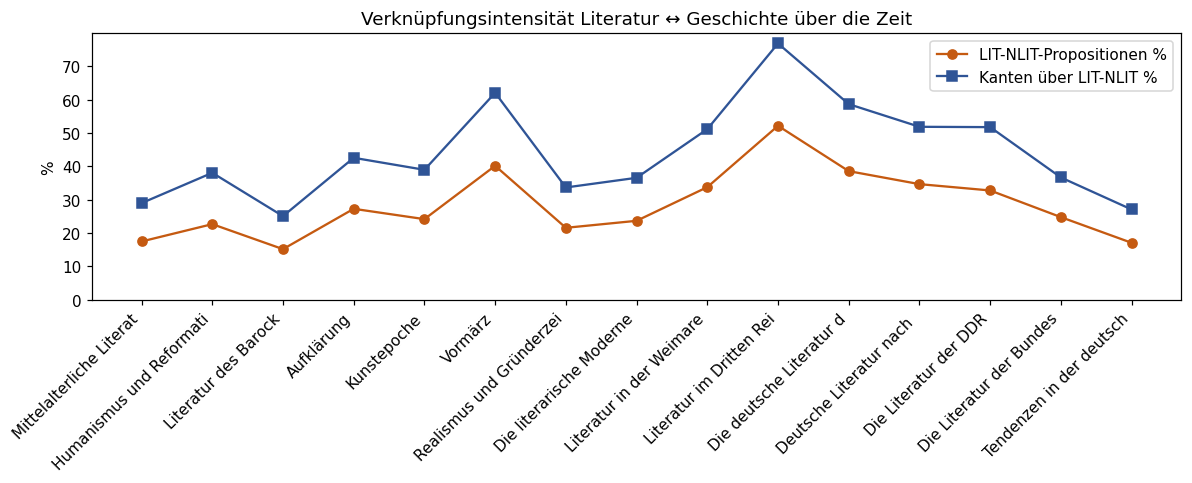

In [10]:
x = range(len(zeit))
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(x, zeit["LIT-NLIT %"], marker="o", label="LIT-NLIT-Propositionen %", color="#C55A11")
ax.plot(x, zeit["über LIT-NLIT %"], marker="s", label="Kanten über LIT-NLIT %", color="#2F5496")
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("%"); ax.set_ylim(bottom=0)
ax.set_title("Verknüpfungsintensität Literatur ↔ Geschichte über die Zeit")
ax.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "zeit_verknuepfung.png", dpi=130, bbox_inches="tight")
plt.show()

## Exporte

**Erzeugte Dateien** (in `analyse_outputs/`):
`nlit_gegenstaende_top40.xlsx`, `lit_nlit_bruecken_top.xlsx`,
`entwicklung_ueber_zeit.xlsx`, `zeit_zusammensetzung.png`, `zeit_verknuepfung.png`.